In [10]:
l = 0.52
nu1 = 0.6

p = l / nu1
p0 = 1 / (1 + p + p**2 + p**3)
pf = p**3 * p0
q = 1 - pf
a = l * q
L = (p**2 + 2 * p**3) / (1 + p + p**2 + p**3)
tr = L / l
tsys = tr + q / nu1

print(p0, pf, q, a, L, tr, tsys)

0.30592820884699057 0.19914793328498914 0.8008520667150109 0.41644307469180564 0.6280819434372734 1.2078498912255258 2.542603335750544


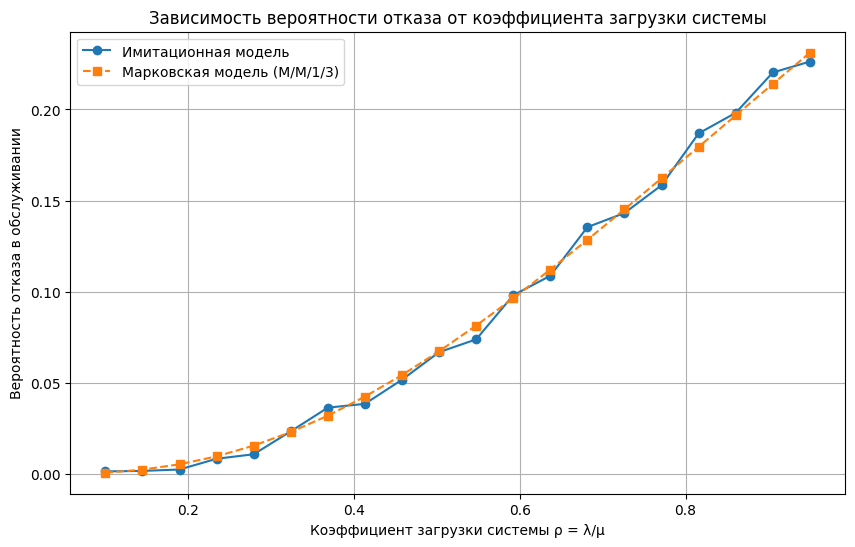

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import heapq


# Функция для экспоненциального распределения
def exp_rv(rate):
    return np.random.exponential(1 / rate)


def simulate_queue(lambda_rate, mu, buffer_size, sim_time):
    """
    Симуляция системы с одним сервером и буфером размером buffer_size.
    Общее число мест в системе = 1 (на сервере) + buffer_size.

    Параметры:
      lambda_rate - интенсивность поступления заявок [1/мс]
      mu          - интенсивность обслуживания [1/мс]
      buffer_size - число мест в накопителе
      sim_time    - время моделирования
    Возвращает:
      stats - словарь с рассчитанными статистиками:
          'idle_probability', 'loss_probability', 'relative_throughput',
          'absolute_throughput', 'avg_queue_length', 'avg_waiting_time', 'avg_time_in_system'
    """

    total_capacity = 1 + buffer_size  # сервер + накопитель
    current_time = 0.0
    # Инициализация событий: событие "прибытие" и "отбытие"
    next_arrival = exp_rv(lambda_rate)
    next_departure = None  # если сервер пуст
    # Очередь (храним время поступления заявок для расчёта времени ожидания)
    queue = []
    # Для сервера: если занят, будем хранить время поступления заявки, которая в обслуживании
    in_service_arrival = None

    # Счетчики статистик
    n_arrivals = 0
    n_rejected = 0
    n_served = 0

    # Для расчёта среднего числа заявок в очереди (по времени)
    area_queue = 0.0
    last_event_time = 0.0

    # Суммарное время ожидания (в очереди) для обслуженных заявок
    total_waiting_time = 0.0
    # Суммарное время пребывания заявки в системе (ожидание+обслуживание)
    total_system_time = 0.0
    # Для расчёта времени простоя (система пуста: ни в обслуживании, ни в очереди)
    idle_time = 0.0

    # Основной цикл симуляции
    while current_time < sim_time:
        # Определяем время следующего события (приход или окончание обслуживания)
        if next_departure is None:
            next_event_time = next_arrival
            event_type = "arrival"
        else:
            if next_arrival < next_departure:
                next_event_time = next_arrival
                event_type = "arrival"
            else:
                next_event_time = next_departure
                event_type = "departure"

        # Обновление статистик по времени
        dt = next_event_time - current_time
        # Число заявок в очереди (не обслуживаемых) равно len(queue)
        area_queue += len(queue) * dt

        # Если система пуста (нет заявки в обслуживании и очередь пуста)
        if (in_service_arrival is None) and (len(queue) == 0):
            idle_time += dt

        current_time = next_event_time

        if event_type == "arrival":
            n_arrivals += 1
            # Проверяем, есть ли место в системе
            current_system = (0 if in_service_arrival is None else 1) + len(queue)
            if current_system < total_capacity:
                # заявка принята
                if in_service_arrival is None:
                    # сервер свободен – начинаем обслуживание сразу
                    in_service_arrival = current_time
                    service_time = exp_rv(mu)
                    next_departure = current_time + service_time
                else:
                    # сервер занят – заявка встает в очередь
                    queue.append(current_time)
            else:
                # отказ в обслуживании, заявка отвергнута
                n_rejected += 1

            # Планируем следующее прибытие
            next_arrival = current_time + exp_rv(lambda_rate)

        else:  # event_type == 'departure'
            # Завершается обслуживание заявки, начавшей обслуживание в in_service_arrival
            arrival_time = in_service_arrival
            waiting_time = (
                arrival_time - arrival_time
            )  # для обслуживаемой заявки waiting = 0
            # Если заявка ждала в очереди, время ожидания будет рассчитано ниже
            # Фиксируем общее время пребывания: время ожидания + обслуживание
            total_system_time += current_time - arrival_time
            n_served += 1

            # Если в очереди есть заявки, переводим первую в обслуживание
            if queue:
                # Из очереди забираем первую заявку (FIFO)
                waiting_arrival = queue.pop(0)
                # Время ожидания для этой заявки = current_time - waiting_arrival
                total_waiting_time += current_time - waiting_arrival
                in_service_arrival = waiting_arrival
                service_time = exp_rv(mu)
                next_departure = current_time + service_time
                # Для этой заявки время в системе = (current_time - waiting_arrival) + service_time
                total_system_time += current_time - waiting_arrival + service_time
                n_served += 1  # эта заявка будет обслужена (учитываем сразу)
            else:
                # Очередь пуста – сервер становится свободен
                in_service_arrival = None
                next_departure = None

    # По окончании симуляции рассчитываем метрики
    idle_probability = idle_time / sim_time
    loss_probability = n_rejected / n_arrivals if n_arrivals > 0 else 0
    relative_throughput = 1 - loss_probability
    absolute_throughput = (n_arrivals - n_rejected) / sim_time
    avg_queue_length = area_queue / sim_time
    avg_waiting_time = total_waiting_time / (n_served if n_served > 0 else 1)
    avg_time_in_system = total_system_time / (n_served if n_served > 0 else 1)

    stats = {
        "idle_probability": idle_probability,
        "loss_probability": loss_probability,
        "relative_throughput": relative_throughput,
        "absolute_throughput": absolute_throughput,
        "avg_queue_length": avg_queue_length,
        "avg_waiting_time": avg_waiting_time,
        "avg_time_in_system": avg_time_in_system,
        "n_arrivals": n_arrivals,
        "n_rejected": n_rejected,
        "n_served": n_served,
    }
    return stats


def markov_loss_probability(lambda_rate, mu, K):
    """
    Для системы M/M/1/K, где K - общее число мест в системе (сервис+буфер).
    Вычисляется вероятность того, что система находится в состоянии K.
    При ρ != 1:
      π0 = (1-ρ)/(1-ρ^(K+1)), π_K = ρ^K * π0
    """
    rho = lambda_rate / mu
    if abs(rho - 1.0) > 1e-8:
        pi0 = (1 - rho) / (1 - rho ** (K + 1))
    else:
        pi0 = 1 / (K + 1)
    piK = (rho**K) * pi0
    return piK


# =======================
# Основной блок моделирования и построения графика
# =======================

# Заданные параметры
lambda_fixed = 0.52  # [1/мс]
mu = 0.6  # [1/мс]
buffer_size = 2  # двухместный накопитель (общая ёмкость = 3)
sim_time = 10000  # время моделирования (мс)

# Моделирование для фиксированных параметров
stats = simulate_queue(lambda_fixed, mu, buffer_size, sim_time)
#

# Построение графика зависимости вероятности отказа в обслуживании от коэффициента загрузки
# Вариируем λ, таким образом, коэффициент загрузки ρ = λ/μ
rho_values = np.linspace(0.1, 0.95, 20)
lambda_values = rho_values * mu

sim_loss = []  # отказ по симуляции
markov_loss = []  # отказ по Марковской модели
n_runs = (
    3  # для уменьшения случайной изменчивости можно повторить симуляцию несколько раз
)

for lam in lambda_values:
    losses = []
    for _ in range(n_runs):
        st = simulate_queue(lam, mu, buffer_size, sim_time)
        losses.append(st["loss_probability"])
    sim_loss.append(np.mean(losses))
    markov_loss.append(
        markov_loss_probability(lam, mu, 1 + buffer_size)
    )  # общее число мест = 3

plt.figure(figsize=(10, 6))
plt.plot(rho_values, sim_loss, "o-", label="Имитационная модель")
plt.plot(rho_values, markov_loss, "s--", label="Марковская модель (M/M/1/3)")
plt.xlabel("Коэффициент загрузки системы ρ = λ/μ")
plt.ylabel("Вероятность отказа в обслуживании")
plt.title("Зависимость вероятности отказа от коэффициента загрузки системы")
plt.legend()
plt.grid(True)
plt.show()